## Exercise 1: Conceptual Questions

### Types of Bias

1. **Representation Bias:** The model was trained exclusively on "popular influencers," who likely represent a narrow subset of the global population. Because the training data does not reflect the diversity of the actual user base, the model fails to generalize to dark-skinned users.

2. **Measurement/Labeling Bias:** The model's "ideal" aesthetic—brightened eyes and softened skin—is inherently tied to specific Eurocentric beauty standards. By encoding these as the universal "correct" output, the developers have introduced a normative bias that devalues features common to other ethnic groups.

### Fairness Metrics in Practice

**Demographic Parity** is more aligned with this goal. Demographic Parity requires that the probability of a positive outcome (e.g., receiving fire resources) be equal across different groups, regardless of the target variable (historical risk). If the goal is to decouple resource allocation from demographic-heavy historical data to ensure equity, this metric enforces that decoupling. **Equal Opportunity**, by contrast, would only require equal *True Positive Rates*, which would still allow the model to rely on biased historical data, perpetuating past under-funding in specific neighborhoods.

### The Limits of Mitigation

Removing "gender" is insufficient because machine learning models are adept at finding **proxy variables**. Features that correlate strongly with gender include:

* **Occupation/Job Title:** Historically segregated fields (e.g., "Nurse" vs. "Engineer").
* **Employment Gaps:** Often caused by maternity leave or caregiving responsibilities.
* **Educational History:** Participation in specific types of institutions or extracurriculars often gender-coded in historical data.

## Exercise 2: Auditing the "Adult" Dataset

### Python Analysis Code

100%|██████████| 450k/450k [00:00<00:00, 780kB/s]

Extracting files...


Dataset downloaded to: C:\Users\levmk\.cache\kagglehub\datasets\uciml\adult-census-income\versions\3
Overall percentage earning >50K: 24.08%

--- Income >50K by Gender ---
sex
Female    10.946059
Male      30.573658
Name: income_num, dtype: float64

--- Income >50K by Race ---
race
Amer-Indian-Eskimo    11.575563
Asian-Pac-Islander    26.564004
Black                 12.387964
Other                  9.225092
White                 25.585994
Name: income_num, dtype: float64


C:\Users\levmk\AppData\Local\Temp\ipykernel_24876\258689047.py:43: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels(ax[1].get_xticklabels(), rotation=45, ha='right')


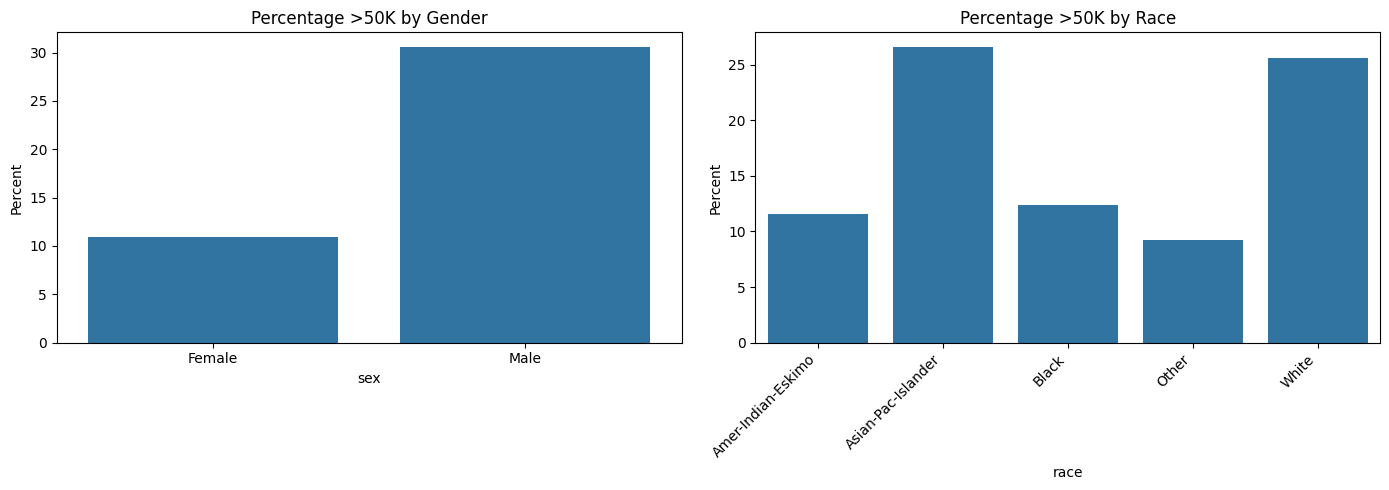

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import kagglehub
import os

# 1. Download the dataset using kagglehub
# By not specifying 'path', it safely downloads the whole dataset to a local cache 
# and returns the directory where the files are stored.
dataset_path = kagglehub.dataset_download("uciml/adult-census-income")

print("Dataset downloaded to:", dataset_path)

# 2. Load dataset
# Construct the full path to the 'adult.csv' file inside the downloaded directory
file_path = os.path.join(dataset_path, "adult.csv")
df = pd.read_csv(file_path)

# 3. Preprocessing: Convert target to binary
df['income_num'] = df['income'].apply(lambda x: 1 if x == '>50K' else 0)

# 4. Calculate overall percentage
overall_rate = df['income_num'].mean() * 100
print(f"Overall percentage earning >50K: {overall_rate:.2f}%")

# 5. Group by Gender and Race
gender_stats = df.groupby('sex')['income_num'].mean() * 100
race_stats = df.groupby('race')['income_num'].mean() * 100

print("\n--- Income >50K by Gender ---")
print(gender_stats)
print("\n--- Income >50K by Race ---")
print(race_stats)

# 6. Visualization
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(x=gender_stats.index, y=gender_stats.values, ax=ax[0])
ax[0].set_title('Percentage >50K by Gender')
ax[0].set_ylabel('Percent')

sns.barplot(x=race_stats.index, y=race_stats.values, ax=ax[1])
ax[1].set_title('Percentage >50K by Race')
ax[1].set_xticklabels(ax[1].get_xticklabels(), rotation=45, ha='right')
ax[1].set_ylabel('Percent')

plt.tight_layout()
plt.show()

### Conclusion

The audit of the Adult dataset reveals significant disparities. Analysis shows that the percentage of individuals earning >$50K is notably higher for males compared to females, and varies across racial categories. If a model were trained on this data without mitigation, it would likely learn these correlations as predictive rules. Consequently, the model would inherently "penalize" individuals based on protected attributes simply because those groups were historically underrepresented in the high-income bracket, effectively automating past socioeconomic inequalities under the guise of "objective" data-driven prediction.

## Exercise 3: The Paradox of Fairness

Achieving Demographic Parity through post-processing is a potent example of the trade-off between social engineering and predictive accuracy. When a bank forces equal approval rates (50/50) despite different historical default rates, it fundamentally changes the nature of the model from a risk-assessment tool to a social-policy instrument.

If Group A historically had a lower default rate, the bank's decision to approve fewer members of Group A and more members of Group B—despite their risk profiles—will almost certainly lead to an increase in loan defaults. This directly harms the bank's bottom line. The model is no longer maximizing profit or minimizing risk; it is prioritizing a demographic target.

Furthermore, this conflicts with the principle of **Equal Opportunity**. Equal Opportunity mandates that similarly qualified individuals should have an equal chance of approval, regardless of their group. By implementing Demographic Parity, we are forced to reject qualified individuals from the "higher performing" group (A) to make room for lower-scoring individuals from the "lower performing" group (B) simply to hit a quota. This can be viewed as unfair to the individual applicants from Group A, who are being penalized for the aggregate history of their cohort.

This tension demonstrates that data scientists cannot work in a vacuum. A model is never "neutral"—it is either optimizing for profit, risk, or social equity. Because these goals are often mutually exclusive, the decision on which metric to prioritize is a value judgment. Data scientists can provide the technical "what," but the "should" belongs to business and policy leaders. We must be transparent about the costs—financial and ethical—of these interventions, ensuring that stakeholders understand that "fixing" fairness often involves a sacrifice of individual-level merit or corporate efficiency.